# 6. Machine Learning Capstone: Mobile Recommender System
---
**Dataset:** https://www.kaggle.com/datasets/valakhorasani/mobile-device-usage-and-user-behavior-dataset  


**Objectives:** Develop and evaluate four recommender models that suggest the optimal next device model for a user based on the demographic content features and ratings derived from their behavior class.

##**1. Import Libraries**

In [ ]:
import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict
warnings.filterwarnings('ignore')

from sklearn.preprocessing   import MultiLabelBinarizer, LabelEncoder, StandardScaler
from sklearn.neighbors        import NearestNeighbors
from sklearn.decomposition    import NMF
from sklearn.metrics          import mean_absolute_error, mean_squared_error
from sklearn.model_selection  import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#CCCCCC', 'axes.labelcolor': '#222222',
    'xtick.color': '#444444', 'ytick.color': '#444444',
    'grid.color': '#EEEEEE', 'font.family': 'sans-serif',
    'axes.titlesize': 12, 'axes.labelsize': 10,
})
PAL = ['#1976D2','#E53935','#388E3C','#F57F17','#7B1FA2',
       '#00838F','#BF360C','#1B5E20','#4A148C','#E65100']

print(f'Device: {DEVICE}')

Device: cpu


## **2. Load Data**

In [ ]:
file_id = '1nPYXBHeofOP-Zt3OV7UgYfqvRgCOgQVe'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
raw_df = pd.read_csv(url)

# Standardise column names
raw_df.columns = (
    raw_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[\s/()]+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

print('=== RAW COLUMNS ===')
print(list(raw_df.columns))
print()
print('=== FIRST 5 ROWS ===')
print(raw_df.head())
print(f'\nShape: {raw_df.shape}')

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f'None of {candidates} found in columns: {list(df.columns)}')

USER_COL   = find_col(raw_df, ['user_id', 'userid'])
ITEM_COL   = find_col(raw_df, ['device_model', 'devicemodel', 'device'])
RATING_COL = find_col(raw_df, ['user_behavior_class', 'user_behaviour_class', 'userbehaviorclass'])
OS_COL     = find_col(raw_df, ['operating_system', 'os', 'operatingsystem'])
AGE_COL    = find_col(raw_df, ['age'])
GENDER_COL = find_col(raw_df, ['gender'])

print(f'\nMapped → user:{USER_COL} | item:{ITEM_COL} | rating:{RATING_COL}')

ratings_df = raw_df[[USER_COL, ITEM_COL, RATING_COL, OS_COL, AGE_COL, GENDER_COL]].copy()
ratings_df.rename(columns={
    USER_COL: 'user', ITEM_COL: 'item', RATING_COL: 'rating',
    OS_COL: 'os', AGE_COL: 'age', GENDER_COL: 'gender'
}, inplace=True)

print('\n=== RATINGS_DF ===')
print(ratings_df.head())
print(f'Shape: {ratings_df.shape}')
print(f'Rating range: {ratings_df["rating"].min()} – {ratings_df["rating"].max()}')
print(f'Unique devices (items): {ratings_df["item"].nunique()}')
print(f'Unique users: {ratings_df["user"].nunique()}')

=== RAW COLUMNS ===
['user_id', 'device_model', 'operating_system', 'app_usage_time_min_day_', 'screen_on_time_hours_day_', 'battery_drain_mah_day_', 'number_of_apps_installed', 'data_usage_mb_day_', 'age', 'gender', 'user_behavior_class']

=== FIRST 5 ROWS ===
   user_id    device_model operating_system  app_usage_time_min_day_  \
0        1  Google Pixel 5          Android                      393   
1        2       OnePlus 9          Android                      268   
2        3    Xiaomi Mi 11          Android                      154   
3        4  Google Pixel 5          Android                      239   
4        5       iPhone 12              iOS                      187   

   screen_on_time_hours_day_  battery_drain_mah_day_  \
0                        6.4                    1872   
1                        4.7                    1331   
2                        4.0                     761   
3                        4.8                    1676   
4                        

In [ ]:
raw_df.head()

,user_id,device_model,operating_system,app_usage_time_min_day_,screen_on_time_hours_day_,battery_drain_mah_day_,number_of_apps_installed,data_usage_mb_day_,age,gender,user_behavior_class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    700 non-null    int64  
 1   device_model               700 non-null    object 
 2   operating_system           700 non-null    object 
 3   app_usage_time_min_day_    700 non-null    int64  
 4   screen_on_time_hours_day_  700 non-null    float64
 5   battery_drain_mah_day_     700 non-null    int64  
 6   number_of_apps_installed   700 non-null    int64  
 7   data_usage_mb_day_         700 non-null    int64  
 8   age                        700 non-null    int64  
 9   gender                     700 non-null    object 
 10  user_behavior_class        700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


## **3. Exploratory Data Analysis (EDA)**

DATASET OVERVIEW
  Unique users   : 700
  Unique devices : 5
  Total ratings  : 700
  Sparsity       : 80.00%
  Avg rating     : 2.99


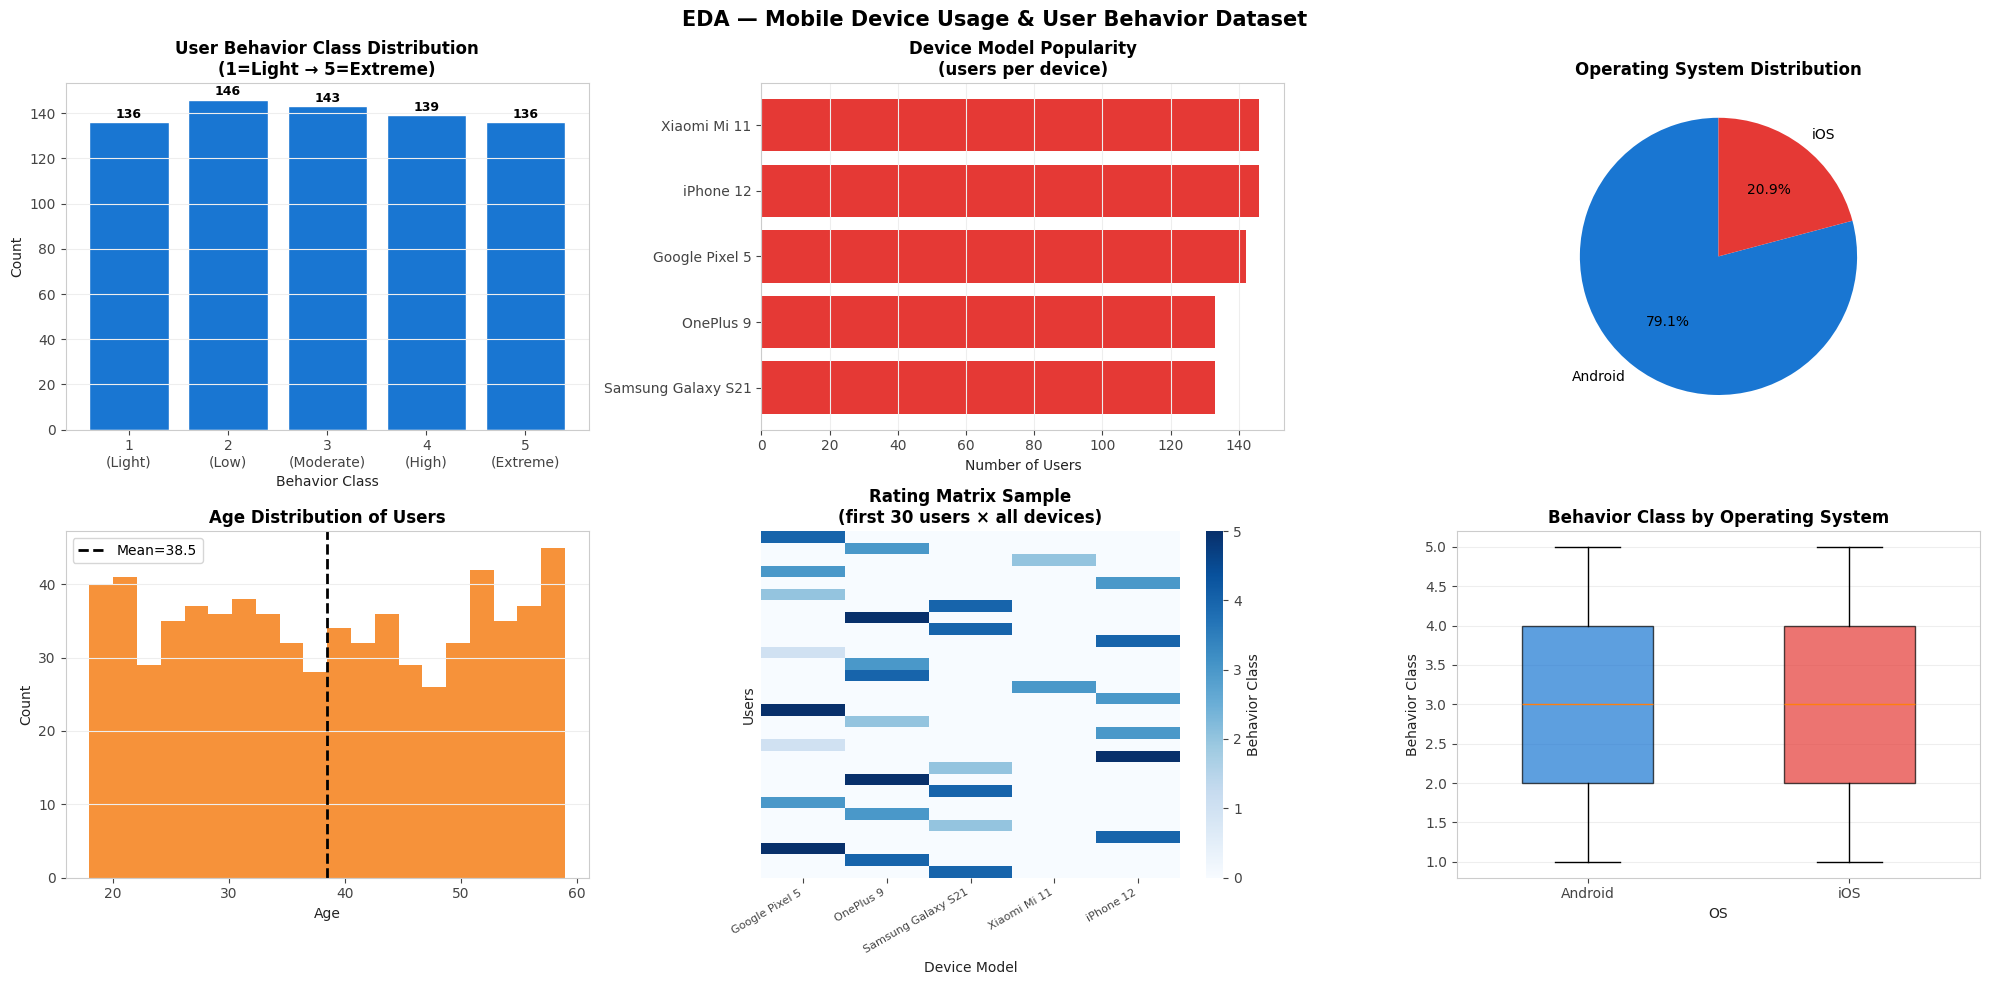

In [ ]:
n_users   = ratings_df['user'].nunique()
n_devices = ratings_df['item'].nunique()
n_ratings = len(ratings_df)
sparsity  = 1 - (n_ratings / (n_users * n_devices))

print('=' * 55)
print('DATASET OVERVIEW')
print('=' * 55)
print(f'  Unique users   : {n_users:,}')
print(f'  Unique devices : {n_devices:,}')
print(f'  Total ratings  : {n_ratings:,}')
print(f'  Sparsity       : {sparsity:.2%}')
print(f'  Avg rating     : {ratings_df["rating"].mean():.2f}')
print('=' * 55)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('EDA — Mobile Device Usage & User Behavior Dataset', fontsize=15, fontweight='bold')

# 1. User Behavior Class distribution (our proxy rating)
ax = axes[0, 0]
rc = ratings_df['rating'].value_counts().sort_index()
labels = {1:'Light', 2:'Low', 3:'Moderate', 4:'High', 5:'Extreme'}
ax.bar([f'{v}\n({labels.get(v,"")})'  for v in rc.index], rc.values, color=PAL[0], edgecolor='white')
for i, c in enumerate(rc.values):
    ax.text(i, c + 2, f'{c:,}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('User Behavior Class Distribution\n(1=Light → 5=Extreme)', fontweight='bold')
ax.set_xlabel('Behavior Class'); ax.set_ylabel('Count'); ax.grid(True, axis='y')

# 2. Device model popularity
ax = axes[0, 1]
rpc = ratings_df['item'].value_counts()
ax.barh(rpc.index[::-1], rpc.values[::-1], color=PAL[1], edgecolor='none')
ax.set_title('Device Model Popularity\n(users per device)', fontweight='bold')
ax.set_xlabel('Number of Users'); ax.grid(True, axis='x')

# 3. OS distribution
ax = axes[0, 2]
os_counts = ratings_df['os'].value_counts()
ax.pie(os_counts.values, labels=os_counts.index, autopct='%1.1f%%',
       colors=PAL[:len(os_counts)], startangle=90)
ax.set_title('Operating System Distribution', fontweight='bold')

# 4. Age distribution
ax = axes[1, 0]
ax.hist(raw_df[AGE_COL], bins=20, color=PAL[3], alpha=0.85, edgecolor='none')
ax.axvline(raw_df[AGE_COL].mean(), color='black', linewidth=2, linestyle='--',
           label=f'Mean={raw_df[AGE_COL].mean():.1f}')
ax.set_title('Age Distribution of Users', fontweight='bold')
ax.set_xlabel('Age'); ax.set_ylabel('Count')
ax.legend(); ax.grid(True, axis='y')

# 5. Rating matrix heatmap (users × devices)
ax = axes[1, 1]
pivot = ratings_df.pivot_table(index='user', columns='item', values='rating', fill_value=0)
# Show first 30 users for readability
sns.heatmap(pivot.iloc[:30], ax=ax, cmap='Blues', cbar_kws={'label': 'Behavior Class'},
            xticklabels=True, yticklabels=False)
ax.set_title('Rating Matrix Sample\n(first 30 users × all devices)', fontweight='bold')
ax.set_xlabel('Device Model'); ax.set_ylabel('Users')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# 6. Behavior class by OS (box plot)
ax = axes[1, 2]
for i, os_val in enumerate(ratings_df['os'].unique()):
    subset = ratings_df[ratings_df['os'] == os_val]['rating']
    ax.boxplot(subset, positions=[i], widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor=PAL[i], alpha=0.7))
ax.set_xticks(range(len(ratings_df['os'].unique())))
ax.set_xticklabels(ratings_df['os'].unique())
ax.set_title('Behavior Class by Operating System', fontweight='bold')
ax.set_xlabel('OS'); ax.set_ylabel('Behavior Class'); ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

## **4. Data Cleaning**

In [ ]:
print('BEFORE CLEANING:')
print(f'  ratings_df : {ratings_df.shape}')
print()

# Missing values
r_nulls = ratings_df.isnull().sum()
print('Null counts:', r_nulls[r_nulls > 0].to_dict() or 'NONE')
ratings_df.dropna(subset=['user', 'item', 'rating'], inplace=True)

# Duplicate rows
n_exact = ratings_df.duplicated().sum()
n_key   = ratings_df.duplicated(subset=['user', 'item']).sum()
print(f'\nDuplicate rows (exact)    : {n_exact}')
print(f'Duplicate user-item pairs : {n_key}')
ratings_df.drop_duplicates(inplace=True)

ratings_df = (
    ratings_df
    .sort_values('rating', ascending=False)
    .drop_duplicates(subset=['user', 'item'])
    .reset_index(drop=True)
)

valid_ratings = ratings_df['rating'].between(1, 5)
invalid_count = (~valid_ratings).sum()
print(f'Invalid ratings (not 1–5): {invalid_count}')
ratings_df = ratings_df[valid_ratings].reset_index(drop=True)

device_meta = (
    ratings_df
    .groupby('item')
    .agg(
        dominant_os=('os', lambda x: x.mode()[0]),
        avg_age=('age', 'mean'),
        dominant_gender=('gender', lambda x: x.mode()[0]),
        avg_behavior=('rating', 'mean'),
        n_users=('user', 'count')
    )
    .reset_index()
)
device_meta.rename(columns={'item': 'device_model'}, inplace=True)

print()
print('AFTER CLEANING:')
print(f'  ratings_df  : {ratings_df.shape}')
print(f'  device_meta : {device_meta.shape}')
print(f'  Users       : {ratings_df["user"].nunique():,}')
print(f'  Devices     : {ratings_df["item"].nunique():,}')
print('\nDevice metadata sample:')
print(device_meta.head())

BEFORE CLEANING:
  ratings_df : (700, 6)

Null counts: NONE

Duplicate rows (exact)    : 0
Duplicate user-item pairs : 0
Invalid ratings (not 1–5): 0

AFTER CLEANING:
  ratings_df  : (700, 6)
  device_meta : (5, 6)
  Users       : 700
  Devices     : 5

Device metadata sample:
         device_model dominant_os    avg_age dominant_gender  avg_behavior  \
0      Google Pixel 5     Android  37.767606            Male      2.915493   
1           OnePlus 9     Android  38.879699            Male      2.977444   
2  Samsung Galaxy S21     Android  39.112782            Male      2.977444   
3        Xiaomi Mi 11     Android  37.767123          Female      2.972603   
4           iPhone 12         iOS  38.958904          Female      3.102740   

   n_users  
0      142  
1      133  
2      133  
3      146  
4      146  


## **5. Train/Test Split & User-Device Matrix**

In [ ]:
SEED = 42
train_df, test_df = train_test_split(
    ratings_df, test_size=0.2, random_state=SEED, stratify=ratings_df['rating']
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df):,} ratings | Test: {len(test_df):,} ratings')


all_users   = ratings_df['user'].unique()
all_devices = ratings_df['item'].unique()

user2idx   = {u: i for i, u in enumerate(all_users)}
device2idx = {d: i for i, d in enumerate(all_devices)}
idx2user   = {i: u for u, i in user2idx.items()}
idx2device = {i: d for d, i in device2idx.items()}

N_USERS   = len(all_users)
N_DEVICES = len(all_devices)
print(f'N_USERS={N_USERS} | N_DEVICES={N_DEVICES}')

utility_matrix = np.zeros((N_USERS, N_DEVICES), dtype=np.float32)
for _, row in train_df.iterrows():
    u = user2idx.get(row['user'])
    d = device2idx.get(row['item'])
    if u is not None and d is not None:
        utility_matrix[u, d] = row['rating']

sparsity = 1 - np.count_nonzero(utility_matrix) / utility_matrix.size
print(f'Utility matrix shape : {utility_matrix.shape}')
print(f'Sparsity             : {sparsity:.2%}')

Train: 560 ratings | Test: 140 ratings
N_USERS=700 | N_DEVICES=5
Utility matrix shape : (700, 5)
Sparsity             : 84.00%


## **6. Content-Based Recommender**

In [ ]:
le_os     = LabelEncoder()
le_gender = LabelEncoder()

device_feat = device_meta.copy()
device_feat['os_enc']     = le_os.fit_transform(device_feat['dominant_os'])
device_feat['gender_enc'] = le_gender.fit_transform(device_feat['dominant_gender'])

device_feat['age_group'] = pd.cut(
    device_feat['avg_age'], bins=[0, 30, 45, 100],
    labels=[0, 1, 2], right=False
).astype(float)

device_feat['behavior_bracket'] = pd.cut(
    device_feat['avg_behavior'], bins=[0, 2.5, 3.5, 6],
    labels=[0, 1, 2], right=False
).astype(float)

FEAT_COLS = ['os_enc', 'age_group', 'gender_enc', 'behavior_bracket']
device_feat_matrix = device_feat[FEAT_COLS].fillna(0).values.astype(np.float32)
device_feat_index  = device_feat['device_model'].tolist()
device_feat_df     = pd.DataFrame(device_feat_matrix, index=device_feat_index, columns=FEAT_COLS)

print(f'Device feature matrix shape: {device_feat_matrix.shape}')
print('Features:', FEAT_COLS)
print(device_feat_df)


def build_user_profile(user_id, train_data, feat_df):
    user_rows  = train_data[train_data['user'] == user_id]
    rated_devs = user_rows['item'].values
    weights    = user_rows['rating'].values.astype(float)

    mask = np.isin(rated_devs, feat_df.index)
    rated_devs = rated_devs[mask]
    weights    = weights[mask]

    if len(rated_devs) == 0:
        return np.zeros(len(feat_df.columns))

    vecs    = feat_df.loc[rated_devs].values
    profile = np.average(vecs, axis=0, weights=weights)
    return profile


def content_based_recommend(user_id, top_n=10):
    profile = build_user_profile(user_id, train_df, device_feat_df)
    sims    = cosine_similarity([profile], device_feat_df.values)[0]

    already_used = set(train_df[train_df['user'] == user_id]['item'])
    dev_ids      = device_feat_df.index.tolist()

    recs = [
        (dev_ids[i], sims[i])
        for i in np.argsort(sims)[::-1]
        if dev_ids[i] not in already_used
    ][:top_n]
    return recs

sample_user = train_df['user'].iloc[0]
recs_cb     = content_based_recommend(sample_user, top_n=5)

print(f'\nContent-Based Recommendations for user: {sample_user}')
print(f'{"Device Model":<30} {"Similarity"}')
print('-' * 45)
for dev, score in recs_cb:
    print(f'{dev:<30} {score:.4f}')

Device feature matrix shape: (5, 4)
Features: ['os_enc', 'age_group', 'gender_enc', 'behavior_bracket']
                    os_enc  age_group  gender_enc  behavior_bracket
Google Pixel 5         0.0        1.0         1.0               1.0
OnePlus 9              0.0        1.0         1.0               1.0
Samsung Galaxy S21     0.0        1.0         1.0               1.0
Xiaomi Mi 11           0.0        1.0         0.0               1.0
iPhone 12              1.0        1.0         0.0               1.0

Content-Based Recommendations for user: 483
Device Model                   Similarity
---------------------------------------------
Xiaomi Mi 11                   0.8165
Samsung Galaxy S21             0.6667
OnePlus 9                      0.6667
Google Pixel 5                 0.6667


## **7. Model: KNN-Based Collaborative Filtering**

KNN fitted on (700, 5) matrix with K=10

KNN Recommendations for user: 483
Device Model                   Weighted Score
------------------------------------------------


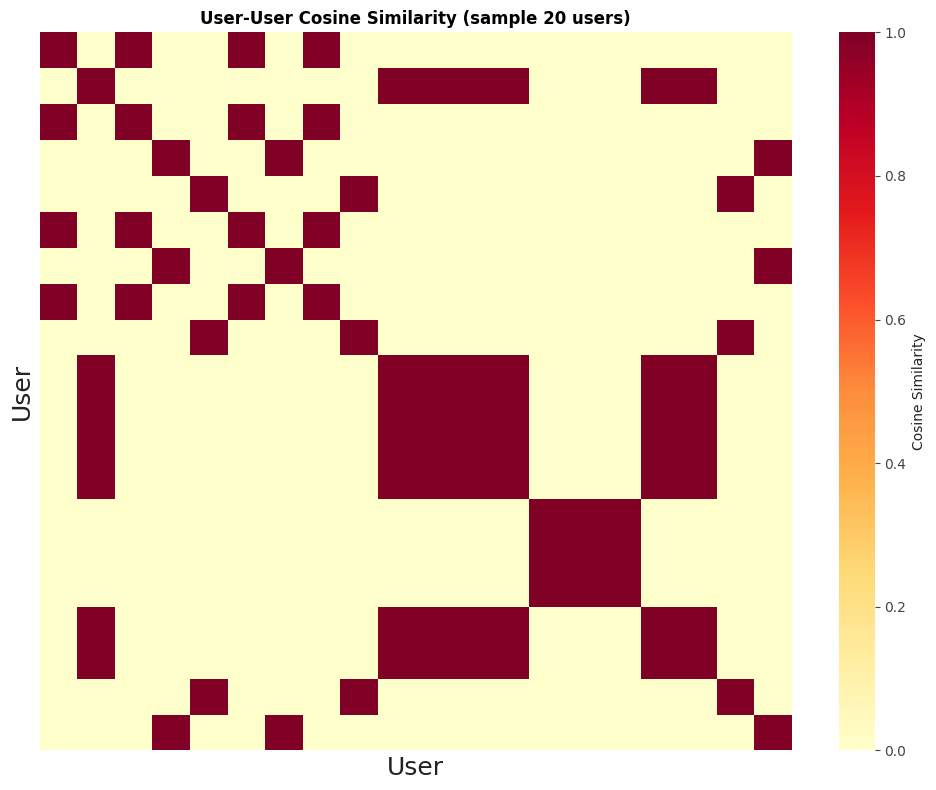

In [ ]:
K_NEIGHBOURS = 10

knn_model = NearestNeighbors(
    n_neighbors=K_NEIGHBOURS + 1,
    metric='cosine',
    algorithm='brute',
    n_jobs=-1,
)
knn_model.fit(utility_matrix)
print(f'KNN fitted on {utility_matrix.shape} matrix with K={K_NEIGHBOURS}')


def knn_recommend(user_id, top_n=10):
    if user_id not in user2idx:
        return []

    u_idx       = user2idx[user_id]
    user_vector = utility_matrix[u_idx].reshape(1, -1)

    distances, indices = knn_model.kneighbors(user_vector)
    neighbour_indices  = indices[0][1:]
    neighbour_sims     = 1 - distances[0][1:]

    already_used = set(np.where(utility_matrix[u_idx] > 0)[0])

    scores = defaultdict(float)
    counts = defaultdict(float)
    for n_idx, sim in zip(neighbour_indices, neighbour_sims):
        for d_idx in np.where(utility_matrix[n_idx] > 0)[0]:
            if d_idx not in already_used:
                scores[d_idx] += sim * utility_matrix[n_idx, d_idx]
                counts[d_idx] += sim

    recs = [
        (idx2device[d_idx], scores[d_idx] / (counts[d_idx] + 1e-9))
        for d_idx in scores
    ]
    recs.sort(key=lambda x: x[1], reverse=True)
    return recs[:top_n]

recs_knn = knn_recommend(sample_user, top_n=5)
print(f'\nKNN Recommendations for user: {sample_user}')
print(f'{"Device Model":<30} {"Weighted Score"}')
print('-' * 48)
for dev, score in recs_knn:
    print(f'{dev:<30} {score:.4f}')

sample_users = train_df['user'].unique()[:20]
sub_matrix   = utility_matrix[[user2idx[u] for u in sample_users]]
sim_matrix   = cosine_similarity(sub_matrix)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_matrix, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
            xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Cosine Similarity'})
ax.set_title('User-User Cosine Similarity (sample 20 users)', fontweight='bold')
ax.set_xlabel('User', fontsize='18'); ax.set_ylabel('User', fontsize='18')
plt.tight_layout()
plt.show()

## **8. Model: NMF Collaborative Filtering**

NMF fitted | W shape: (700, 5) | H shape: (5, 5)
Reconstruction error: 13.2449

NMF Recommendations for user: 483
Device Model                   Predicted Score
------------------------------------------------
Samsung Galaxy S21             0.0000
Google Pixel 5                 0.0000
Xiaomi Mi 11                   0.0000
OnePlus 9                      0.0000


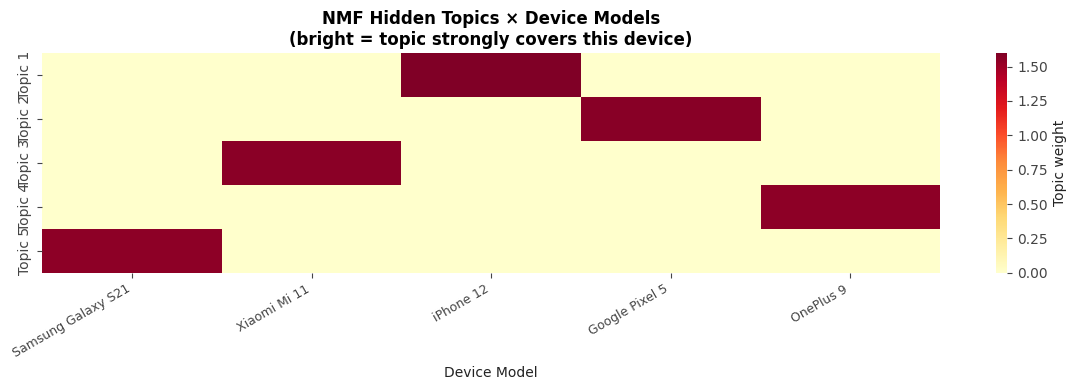

In [ ]:
N_COMPONENTS = 5

nmf_model = NMF(
    n_components=N_COMPONENTS,
    init='nndsvda',
    max_iter=300,
    random_state=SEED,
    alpha_W=0.1,
    alpha_H=0.1,
)

W = nmf_model.fit_transform(utility_matrix)
H = nmf_model.components_
nmf_predictions = np.dot(W, H)

print(f'NMF fitted | W shape: {W.shape} | H shape: {H.shape}')
print(f'Reconstruction error: {nmf_model.reconstruction_err_:.4f}')


def nmf_recommend(user_id, top_n=10):
    if user_id not in user2idx:
        return []
    u_idx         = user2idx[user_id]
    predicted_row = nmf_predictions[u_idx]
    already_used  = set(np.where(utility_matrix[u_idx] > 0)[0])

    recs = [
        (idx2device[i], predicted_row[i])
        for i in np.argsort(predicted_row)[::-1]
        if i not in already_used
    ][:top_n]
    return recs

recs_nmf = nmf_recommend(sample_user, top_n=5)
print(f'\nNMF Recommendations for user: {sample_user}')
print(f'{"Device Model":<30} {"Predicted Score"}')
print('-' * 48)
for dev, score in recs_nmf:
    print(f'{dev:<30} {score:.4f}')

fig, ax = plt.subplots(figsize=(12, 4))
topic_labels = [f'Topic {i+1}' for i in range(N_COMPONENTS)]
sns.heatmap(H, ax=ax, cmap='YlOrRd',
            xticklabels=all_devices,
            yticklabels=topic_labels,
            cbar_kws={'label': 'Topic weight'})
ax.set_title('NMF Hidden Topics × Device Models\n'
             '(bright = topic strongly covers this device)',
             fontweight='bold')
ax.set_xlabel('Device Model')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('nmf_topics.png', dpi=150, bbox_inches='tight')
plt.show()

## **9. Model: Neural Network Embedding Collaborative Filtering**

NCF Training | 700 users | 5 devices | embed_dim=16
Params: 12,369

  Epoch   1/30 | train_loss=10.4977 | val_loss=9.6687 | patience=0/5
  Epoch   5/30 | train_loss=10.0349 | val_loss=9.1746 | patience=0/5
  Epoch  10/30 | train_loss=9.1208 | val_loss=8.3249 | patience=0/5
  Epoch  15/30 | train_loss=7.8105 | val_loss=7.0009 | patience=0/5
  Epoch  20/30 | train_loss=5.2863 | val_loss=5.0516 | patience=0/5
  Epoch  25/30 | train_loss=2.6866 | val_loss=3.0356 | patience=0/5
  Epoch  30/30 | train_loss=1.6276 | val_loss=1.9477 | patience=0/5


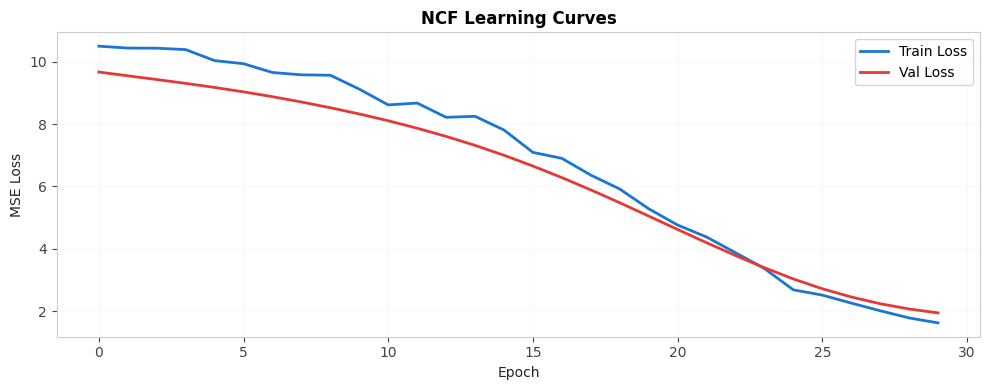

In [ ]:
EMBED_DIM  = 16
HIDDEN_DIM = 32
EPOCHS     = 30
BATCH_SIZE = 128
LR         = 1e-3
PATIENCE   = 5


class RatingDataset(Dataset):
    def __init__(self, df, user2idx, device2idx):
        rows = [(user2idx[r['user']], device2idx[r['item']], float(r['rating']))
                for _, r in df.iterrows()
                if r['user'] in user2idx and r['item'] in device2idx]
        self.users   = torch.tensor([x[0] for x in rows], dtype=torch.long)
        self.devices = torch.tensor([x[1] for x in rows], dtype=torch.long)
        self.ratings = torch.tensor([x[2] for x in rows], dtype=torch.float32)

    def __len__(self):  return len(self.ratings)
    def __getitem__(self, idx):
        return self.users[idx], self.devices[idx], self.ratings[idx]


class NeuralCollaborativeFilter(nn.Module):
    def __init__(self, n_users, n_devices, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.user_embed   = nn.Embedding(n_users,   embed_dim)
        self.device_embed = nn.Embedding(n_devices, embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 1),
        )
        nn.init.normal_(self.user_embed.weight,   std=0.01)
        nn.init.normal_(self.device_embed.weight, std=0.01)

    def forward(self, user_idx, device_idx):
        u = self.user_embed(user_idx)
        d = self.device_embed(device_idx)
        x = torch.cat([u, d], dim=1)
        return self.mlp(x).squeeze(-1)


train_ds     = RatingDataset(train_df, user2idx, device2idx)
test_ds      = RatingDataset(test_df,  user2idx, device2idx)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

ncf_model = NeuralCollaborativeFilter(N_USERS, N_DEVICES).to(DEVICE)
optimizer  = torch.optim.Adam(ncf_model.parameters(), lr=LR, weight_decay=1e-5)
criterion  = nn.MSELoss()

train_losses, val_losses = [], []
best_val_loss, patience_counter, best_state = float('inf'), 0, None

print(f'NCF Training | {N_USERS} users | {N_DEVICES} devices | embed_dim={EMBED_DIM}')
print(f'Params: {sum(p.numel() for p in ncf_model.parameters()):,}')
print()

for epoch in range(1, EPOCHS + 1):
    ncf_model.train()
    t_loss = 0
    for u, d, r in train_loader:
        u, d, r = u.to(DEVICE), d.to(DEVICE), r.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        pred = ncf_model(u, d)
        loss = criterion(pred, r)
        loss.backward()
        optimizer.step()
        t_loss += loss.item() / len(train_loader)

    ncf_model.eval()
    v_loss = 0
    with torch.no_grad():
        for u, d, r in test_loader:
            u, d, r = u.to(DEVICE), d.to(DEVICE), r.to(DEVICE)
            pred    = ncf_model(u, d)
            v_loss += criterion(pred, r).item() / len(test_loader)

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val_loss:
        best_val_loss    = v_loss
        best_state       = {k: v.clone() for k, v in ncf_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/{EPOCHS} | train_loss={t_loss:.4f} | '
              f'val_loss={v_loss:.4f} | patience={patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'  Early stop at epoch {epoch}')
        break

ncf_model.load_state_dict(best_state)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, color=PAL[0], linewidth=2, label='Train Loss')
ax.plot(val_losses,   color=PAL[1], linewidth=2, label='Val Loss')
ax.set_title('NCF Learning Curves', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


def ncf_recommend(user_id, top_n=10):
    if user_id not in user2idx:
        return []
    ncf_model.eval()
    u_idx        = user2idx[user_id]
    already_used = set(np.where(utility_matrix[u_idx] > 0)[0])
    candidates   = [i for i in range(N_DEVICES) if i not in already_used]

    with torch.no_grad():
        u_t = torch.tensor([u_idx] * len(candidates), dtype=torch.long).to(DEVICE)
        d_t = torch.tensor(candidates, dtype=torch.long).to(DEVICE)
        scores = ncf_model(u_t, d_t).cpu().numpy()

    recs = sorted(zip([idx2device[i] for i in candidates], scores),
                  key=lambda x: x[1], reverse=True)
    return recs[:top_n]

## **10. Evaluation of All Models**

In [ ]:
TOP_N = 5


def evaluate_rating_prediction(pred_fn, test_data):
    y_true, y_pred = [], []
    for _, row in test_data.iterrows():
        u, d, r = row['user'], row['item'], row['rating']
        if u not in user2idx or d not in device2idx:
            continue
        p = pred_fn(user2idx[u], device2idx[d])
        y_true.append(r)
        y_pred.append(p)

    if len(y_true) == 0:
        return {'MAE': np.nan, 'RMSE': np.nan}

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}


def evaluate_ranking(rec_fn, test_data, top_n=TOP_N):
    precisions, recalls = [], []
    for user_id in test_data['user'].unique():
        actual = set(test_data[test_data['user'] == user_id]['item'])
        if len(actual) == 0:
            continue
        recs = rec_fn(user_id, top_n=top_n)
        if not recs:
            continue
        rec_set = set([r[0] for r in recs])
        hits    = len(actual & rec_set)
        precisions.append(hits / top_n)
        recalls.append(hits / len(actual))

    return {
        f'Precision@{top_n}': round(np.mean(precisions), 4) if precisions else 0,
        f'Recall@{top_n}':    round(np.mean(recalls),    4) if recalls    else 0,
    }


def knn_predict(u_idx, d_idx):
    user_vec = utility_matrix[u_idx].reshape(1, -1)
    dists, idxs = knn_model.kneighbors(user_vec)

    neighbour_idxs = idxs[0][1:]
    neighbour_sims = 1 - dists[0][1:]

    ratings = utility_matrix[neighbour_idxs, d_idx]
    mask    = ratings > 0

    if mask.sum() == 0:
        return float(utility_matrix[u_idx].mean() or 3.0)

    valid_ratings = ratings[mask]
    valid_weights = neighbour_sims[mask]

    if valid_weights.sum() == 0:
        return float(np.mean(valid_ratings))
    else:
        return float(np.average(valid_ratings, weights=valid_weights))
    if mask.sum() == 0:
        return float(utility_matrix[u_idx].mean() or 3.0)
    return float(np.average(ratings[mask], weights=neighbour_sims[mask]))

def nmf_predict(u_idx, d_idx):
    return float(nmf_predictions[u_idx, d_idx])

def ncf_predict(u_idx, d_idx):
    ncf_model.eval()
    with torch.no_grad():
        u = torch.tensor([u_idx], dtype=torch.long).to(DEVICE)
        d = torch.tensor([d_idx], dtype=torch.long).to(DEVICE)
        return float(ncf_model(u, d).item())

eval_results = {}

# Content-Based: ranking metrics only (no rating prediction)
cb_rank = evaluate_ranking(content_based_recommend, test_df)
eval_results['Content-Based'] = {'MAE': 'N/A', 'RMSE': 'N/A', **cb_rank}

# KNN
knn_rating = evaluate_rating_prediction(knn_predict, test_df)
knn_rank   = evaluate_ranking(knn_recommend, test_df)
eval_results['KNN'] = {**knn_rating, **knn_rank}

# NMF
nmf_rating = evaluate_rating_prediction(nmf_predict, test_df)
nmf_rank   = evaluate_ranking(nmf_recommend, test_df)
eval_results['NMF'] = {**nmf_rating, **nmf_rank}

# NCF
ncf_rating = evaluate_rating_prediction(ncf_predict, test_df)
ncf_rank   = evaluate_ranking(ncf_recommend, test_df)
eval_results['NCF (Neural)'] = {**ncf_rating, **ncf_rank}

eval_table = pd.DataFrame(eval_results).T.reset_index()
eval_table.rename(columns={'index': 'Model'}, inplace=True)

print()
print('=' * 75)
print('MODEL EVALUATION RESULTS')
print('=' * 75)
print(eval_table.to_string(index=False))
print()


MODEL EVALUATION RESULTS
        Model     MAE    RMSE Precision@5 Recall@5
Content-Based     N/A     N/A         0.2      1.0
          KNN  1.9357  2.3315      0.1586   0.7929
          NMF  2.9929  3.3026         0.2      1.0
 NCF (Neural)  1.3266  1.5759         0.2      1.0



## **11. Evaluation Visualisation**

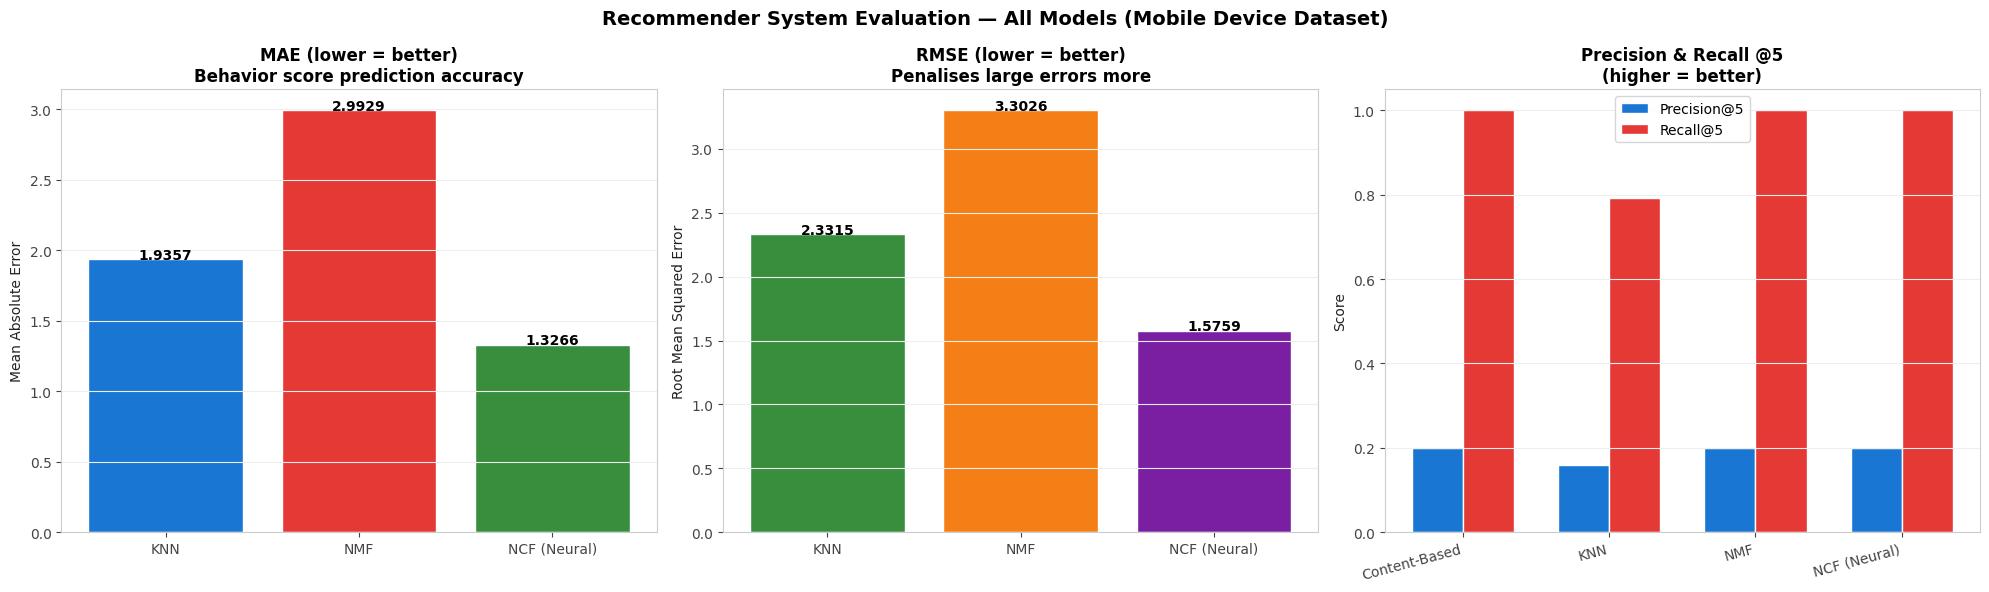

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Recommender System Evaluation — All Models (Mobile Device Dataset)',
             fontsize=14, fontweight='bold')

models = list(eval_results.keys())

# Chart 1: MAE
ax = axes[0]
mae_models = [(m, float(v['MAE'])) for m, v in eval_results.items() if v['MAE'] != 'N/A']
if mae_models:
    names, vals = zip(*mae_models)
    bars = ax.bar(names, vals, color=PAL[:len(names)], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('MAE (lower = better)\nBehavior score prediction accuracy', fontweight='bold')
ax.set_ylabel('Mean Absolute Error'); ax.grid(True, axis='y')

# Chart 2: RMSE
ax = axes[1]
rmse_models = [(m, float(v['RMSE'])) for m, v in eval_results.items() if v['RMSE'] != 'N/A']
if rmse_models:
    names, vals = zip(*rmse_models)
    bars = ax.bar(names, vals, color=PAL[2:2+len(names)], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('RMSE (lower = better)\nPenalises large errors more', fontweight='bold')
ax.set_ylabel('Root Mean Squared Error'); ax.grid(True, axis='y')

# Chart 3: Precision vs Recall
ax = axes[2]
p_key = f'Precision@{TOP_N}'
r_key = f'Recall@{TOP_N}'
prec_vals = [float(eval_results[m].get(p_key, 0)) for m in models]
rec_vals  = [float(eval_results[m].get(r_key, 0)) for m in models]
x = np.arange(len(models))
w = 0.35
ax.bar(x - w/2, prec_vals, w, label=f'Precision@{TOP_N}', color=PAL[0], edgecolor='white')
ax.bar(x + w/2, rec_vals,  w, label=f'Recall@{TOP_N}',    color=PAL[1], edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_title(f'Precision & Recall @{TOP_N}\n(higher = better)', fontweight='bold')
ax.set_ylabel('Score'); ax.legend(); ax.grid(True, axis='y')

plt.tight_layout()
plt.show()